## Architecture of LLama3.1 8B

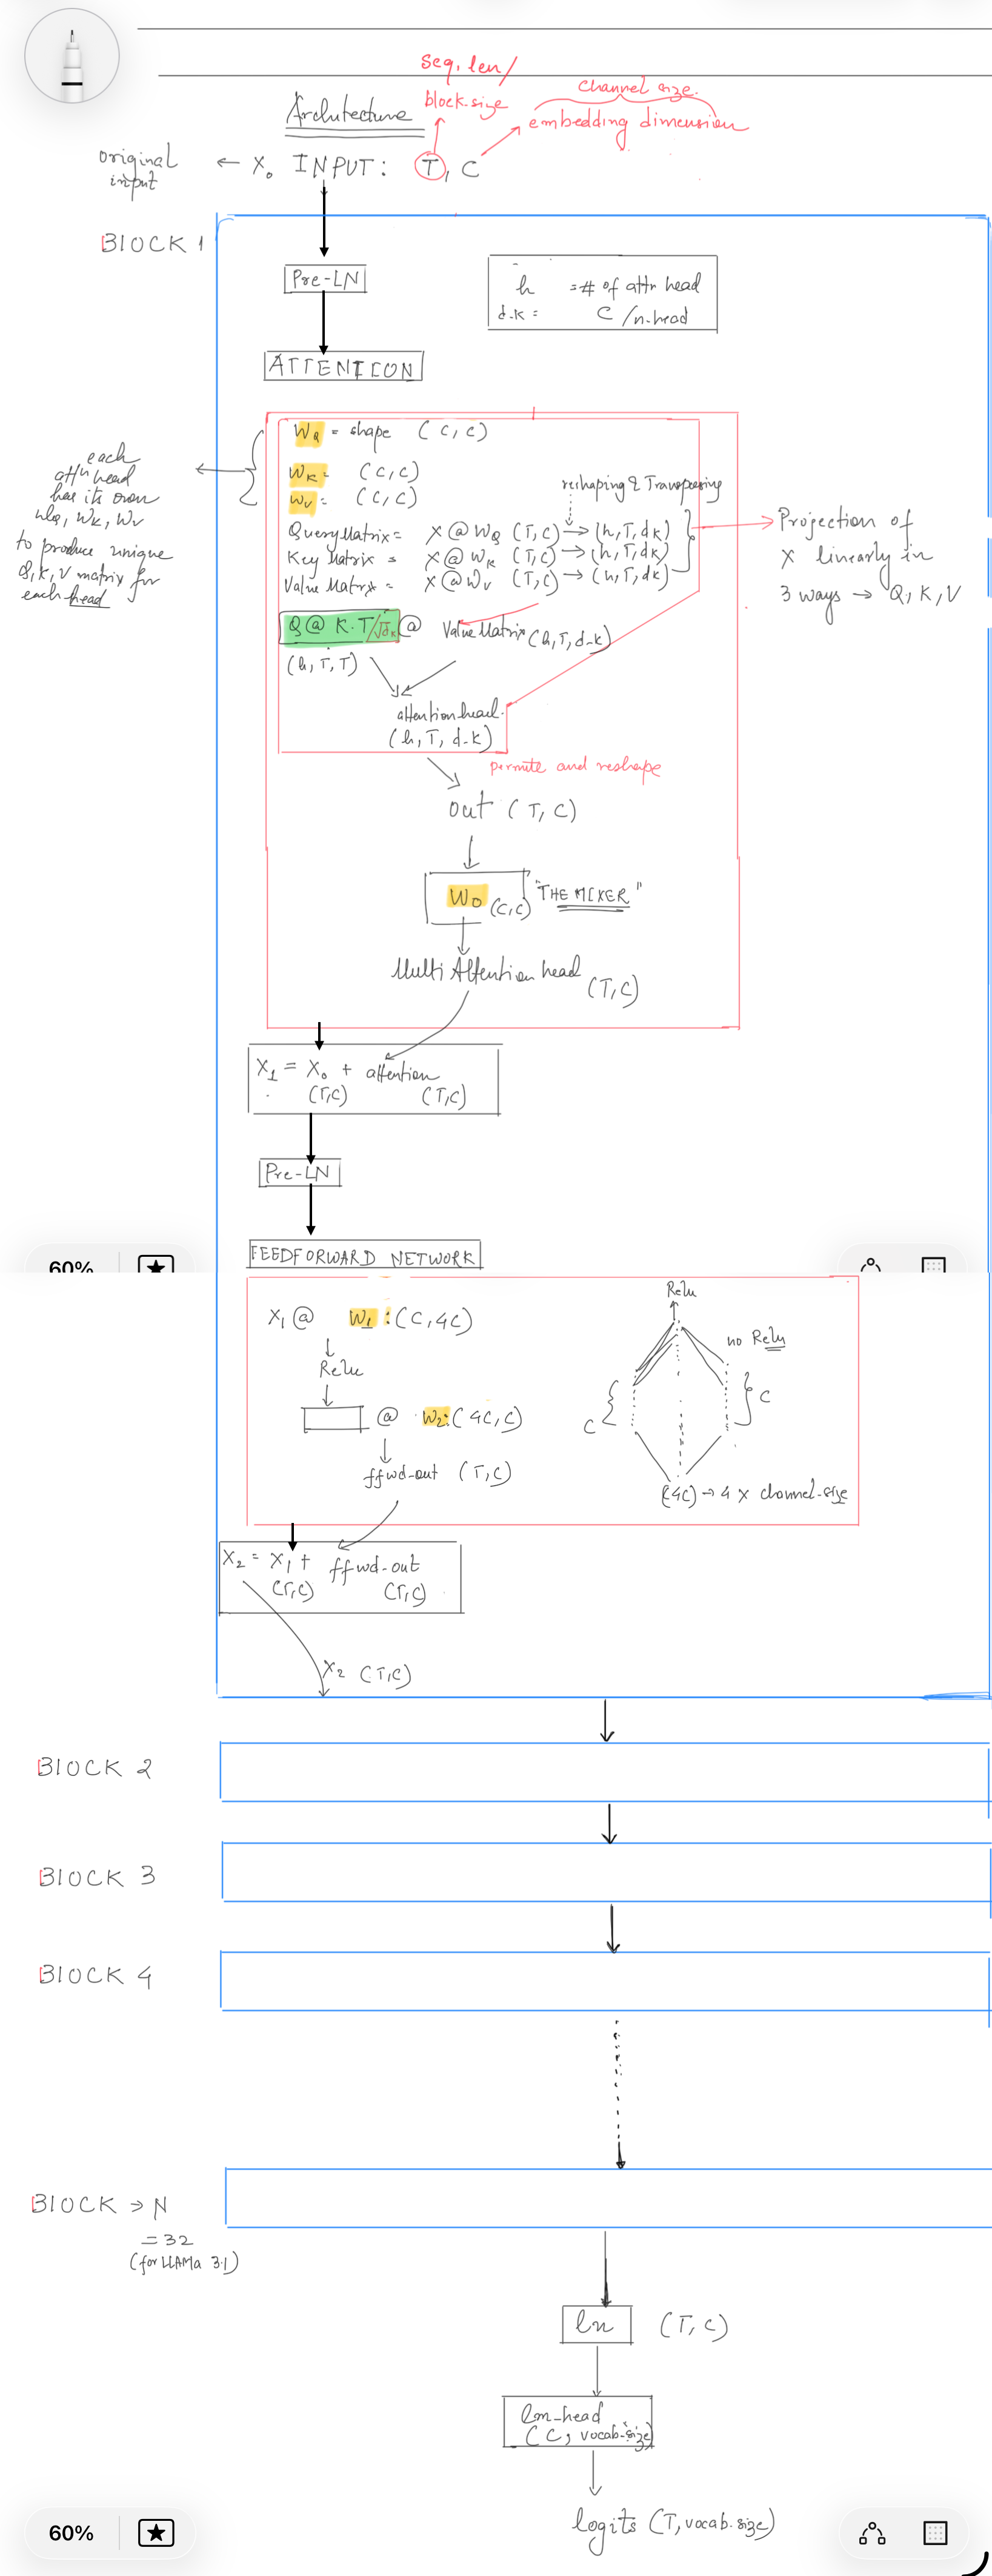

In [1]:
from IPython.display import Image
Image(filename='/kaggle/input/datasets/mehulkumar99/causal-llm-architecture-decoder-architecture/Architecture.png', width=700)

# Fine-tuning Llama 3.1 8B for NL2SQL: 85.59% Execution Accuracy on Spider

**TL;DR:** Fine-tuned Meta's Llama 3.1 8B using QLoRA on Spider NL2SQL benchmark, reaching ***85.59% execution accuracy*** on free Kaggle hardware — up from a 40% Phi-2 baseline. Here's the honest story of what worked, what didn't, and where the ceiling is.

- **Schema representation was the biggest single lever.** Adding sample rows inline to the schema during fine-tuning jumped accuracy ***from 70% to 81%***. The model needed to *learn* how to use sample values — seeing them only at inference gave a **weak 5% gain**. Fine-tuning on augmented schema gave **10%+**.

- **An agentic retry loop with Chain-of-Thought pushed from 81% to 84%.** When the model produces SQL that throws a SQLite execution error, the error message and broken SQL are fed back into the prompt. The model reasons through what went wrong and self-corrects. ***CoT helped even when the model didn't follow the exact format*** — the self-correction within a single generation was the real gain.

- **An evaluation bug was silently understating accuracy.** Two SQL queries returning identical data but different column names were being marked wrong. *Fixing a one-line evaluator bug* recovered 15 examples — ***84.14% → 85.59%***.

- **Cardinality misunderstanding accounts for 13% of remaining failures.** The model consistently misses DISTINCT and uses wrong GROUP BY granularity. We enriched the schema with explicit cardinality labels computed from the actual database. ***The model received the signal and ignored it*** — its SQL generation pattern overrode the reasoning. Fix requires retraining on cardinality-enriched schema, or a larger model.

- ***85.59% is the prompt engineering ceiling for this model.*** Systematic failure analysis of 126 wrong predictions revealed that adding more CoT steps and system instructions actually *hurt* accuracy — errors increased from 23 to 32. The 8B model becomes unstable with longer prompts. ***Reasoning and SQL generation are partially decoupled at 8B scale*** — the model can state a rule correctly and violate it in the same generation.

- **Model-driven tool calling was not attempted.** *Llama 8B is not fine-tuned for autonomous tool selection.* Deterministic hardcoded checks are reliable; letting an 8B model decide when to call tools is not. A production upgrade would use ***GPT-4 as orchestrator*** with the fine-tuned 8B as SQL generator.

- **The agentic pipeline was refactored into LangGraph** — explicit StateGraph with nodes, conditional retry edges, and clean state management.

- **What would actually push beyond 85.59%:** *Retraining* on cardinality-enriched schema (Cat 1 — 13% of failures), retraining on Cat 5/6 failure examples (wrong aggregation and set operation misuse — ***46% of failures combined***). **Prompting alone cannot fix deeply learned wrong patterns in an 8B model.**

---

Check out the Training notebook in my [Training Notebook](https://www.kaggle.com/code/mehulkumar99/spider-question-to-sql-query)

Check out the Inference notebook in my [Generation Notebook](https://www.kaggle.com/code/mehulkumar99/inference-notebook-for-question-to-sql-query)

Check out the original Agent notebook in my [Agent Notebook](https://www.kaggle.com/code/mehulkumar99/agentic-loop-addressing-syntax-errors)

Check out the LangGraph refactored agent in my [LangGraph Agent Notebook](https://www.kaggle.com/code/mehulkumar99/final-langgraph-agent-nl2sql)

Check out the [RAG notebook](https://www.kaggle.com/code/mehulkumar99/rag-sql)

---

## Accuracy Progression

| Step | Change | Execution Accuracy |
|---|---|---|
| Phi-2 2.7B baseline | Unaugmented schema | 40% |
| Llama 3.1 8B | Unaugmented schema | 70.89% |
| + Column order fix | Normalise result tuple order | 72% |
| + Augmented inference | Sample rows, 142 examples | 75% |
| + Token count fix | All 301 wrong/error examples | 77.27% |
| + Augmented fine-tuning | 6,607 training examples | 81% |
| + Agentic loop + CoT | Chain-of-thought + retry on all failures | 84.14% |
| + Evaluation bug fix | Column name normalisation | **85.59%** |
| + LangGraph refactor | StateGraph with conditional retry edges | 85.59% (structural improvement) |

---

## Why NL2SQL?

**Why does this problem matter?** Every analyst who can't write SQL is blocked. Every business decision that needs data goes through a bottleneck — someone who can write queries. NL2SQL removes that bottleneck. And unlike using GPT-4 directly, a fine-tuned 8B model runs on a single GPU you control, costs fractions of a cent per query, and keeps your data local.

**Why is this hard?** You're not generating prose — you're generating code that gets executed against a real database. Either the result set matches, or it doesn't. There's no partial credit from a language model judge.

**Why is Spider a tough benchmark?** It has ~7,000 training examples across 140+ databases spanning hospitals, universities, concerts, and airlines. The validation set uses **entirely different databases** than training — so memorizing schema names gets you nowhere. The model has to generalize to unseen table structures.

**Why does GPT-3.5 fail at 30% of queries?** It pattern-matches on column names, picks wrong tables, and hallucinates joins — because it has no structure to reason through ambiguity. The remaining 30% requires understanding schema relationships, not just language.

**Why does this project get to 85.59%?** Through five targeted decisions: fine-tuning on Spider conventions, schema augmentation with sample values, augmented fine-tuning to close the train-inference mismatch, detailed system instructions for ambiguous joins, and chain-of-thought with an agentic retry loop — reducing syntax errors and pushing accuracy to 85.59%.

---

## Business Value

**Every analyst who can't write SQL is blocked.** Every BI tool that requires hand-written queries has a ceiling. NL2SQL removes that ceiling — and the difference between a 70% and 50% accurate system is the difference between a tool people trust and one they abandon.

---

## Dataset: Spider

- **Train:** 7,000 examples
- **Validation:** 1,034 examples
- **Databases:** 140+ unique DBs (train/val split at the DB level, not the example level)
- **SQL complexity:** Simple SELECTs up to multi-join GROUP BY / HAVING / INTERSECT queries

Here's a quick look at the SQL clause distribution in the training set:

```python
keywords = ['JOIN', 'GROUP BY', 'ORDER BY', 'HAVING', 'INTERSECT', 'UNION', 'EXCEPT', 'LIMIT', 'NESTED', 'END AS', 'CASE']
for kw in keywords:
    train_df[kw] = train_df['query'].str.upper().str.contains(kw)

keyword_counts = train_df[keywords].sum().sort_values(ascending=False)
```

JOIN and ORDER BY dominate. INTERSECT and CASE are rare — and exactly where weaker models fall apart.

One key observation: **the train and validation sets have similar SQL clause distributions**, which is a sign that Spider is well-designed as a benchmark. The model isn't penalized for unseen SQL patterns — only for unseen schema structures.

---

## Schema Formatting: The Underrated Part

Most NL2SQL tutorials dump a raw `CREATE TABLE` string into the prompt. I didn't.

Spider ships with a separate schema dataset (`richardr1126/spider-schema`) containing structured PK/FK annotations. I wrote a custom formatter that turns this into a clean, human-readable representation the model can actually use:

```python
def format_schema(db_id):
    row = schema_lookup[db_id]
    schema = row['Schema (values (type))']
    pk_map = parse_primary_keys(row['Primary Keys'])
    fk_map = parse_foreign_keys(row['Foreign Keys'])

    schema_lines = []
    for table_info in schema.split('|'):
        table_name, cols_info = table_info.strip().split(':')
        col_lines = []
        for col_info in cols_info.split(','):
            col_name = col_info[:col_info.rfind('(')].strip()
            col_type = col_info[col_info.rfind('(')+1 : col_info.rfind(')')].strip()

            annotations = [col_type]
            if col_name == pk_map.get(table_name):
                annotations.append('PK')
            if (table_name, col_name) in fk_map:
                mapping = fk_map[(table_name, col_name)]
                annotations.append(f'FK -> {mapping[0]}.{mapping[1]}')

            col_lines.append(f'- {col_name} ({", ".join(annotations)})')

        schema_lines.append(f'# Table: {table_name}\n## Columns:\n' + '\n'.join(col_lines))

    return '\n\n'.join(schema_lines)
```

**Why this matters:** By explicitly annotating `PK` and `FK -> table.column`, the model can see the join paths directly in the prompt. This structural hint is what turns 50% into 70%.

Example output for database `concert_singer`:

```
# Table: stadium 
## Columns:
- Stadium_ID (number, PK)
- Location (text)
- Name (text)
- Capacity (number)

# Table: concert 
## Columns:
- concert_ID (number, PK)
- Stadium_ID (text, FK -> stadium.Stadium_ID)
- Year (text)
```

---

## Prompt Template

I used Llama 3.1's native chat format with `train_on_responses_only` masking — meaning the model only computes loss on the SQL output, not on the schema or question tokens.

```
<|start_header_id|>system<|end_header_id|>

Convert the natural language question to SQL using the schema below. 
Use SQLite syntax and SQLite functions only.<|eot_id|>

<|start_header_id|>user<|end_header_id|>

### Schema:
{formatted_schema}

### Question:
{question}<|eot_id|>

<|start_header_id|>assistant<|end_header_id|>

{sql_query}<|eot_id|>
```

Before training, I filtered out any examples whose tokenized length exceeded 2048 tokens — there were **82 training examples** excluded. This prevents silent truncation mid-training.

```python
def build_all_prompts(df, schema_lookup):
    texts = []
    skipped = 0
    for i in range(len(df)):
        result = build_prompt(schema_lookup, i, df, inference=False)
        tokens = tokenizer(result['text'], truncation=False, padding=False, add_special_tokens=False)
        if len(tokens['input_ids']) <= 2048:
            texts.append(result)
        else:
            skipped += 1
    print(f"Skipped {skipped} examples over 2048 tokens")
    return Dataset.from_list(texts)
```

---

## Model & QLoRA Setup

**Base model:** `unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit`

I used [Unsloth](https://github.com/unslothai/unsloth) for memory-efficient loading and training — it patches the attention kernels and provides a `train_on_responses_only` utility that handles label masking correctly for instruction-tuned models.

Why Unsloth:
- **Fused operations:** manually derived derivatives calculate gradients and immediately overwrite intermediate data not needed for the next layer
- **Kernel fusion:** reduces VRAM usage during inference, leaving room for KV Cache to handle longer prompts without crashing

```python
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    dtype        = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = 'unsloth',
    random_state   = 42,
)
```

**Memory footprint:** The 8B model in 4-bit uses ~5.6 GB VRAM. LoRA adapters (r=16, targeting all projection layers) add only ~1-2% trainable parameters.

---

## Training Configuration

Trained on Kaggle's **dual T4 GPU environment** (2x 16 GB VRAM). Key config:

```python
training_args = SFTConfig(
    output_dir                  = "./outputs",
    per_device_train_batch_size = 1,
    per_device_eval_batch_size  = 8,
    gradient_accumulation_steps = 8,
    warmup_steps                = 10,
    num_train_epochs            = 3,
    learning_rate               = 5e-5,
    fp16                        = True,
    eval_strategy               = "steps",
    eval_steps                  = 10,
    save_strategy               = "steps",
    save_steps                  = 50,
    save_total_limit            = 3,
    optim                       = "paged_adamw_8bit",
    lr_scheduler_type           = "cosine",
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    save_only_model             = True,
    gradient_checkpointing      = True,
)
```

Key decisions:

- **`gradient_accumulation_steps=8`** — effective batch size of 8 without 8x the VRAM
- **`paged_adamw_8bit`** — offloads optimizer states to CPU RAM when GPU memory is tight
- **Cosine LR schedule** — learning rate decays from 5e-5 back toward zero, preventing aggressive late-training overshooting
- **`save_total_limit=3` + `load_best_model_at_end=True`** — keeps a rolling leaderboard of the 3 best checkpoints by validation loss; best checkpoint loaded automatically at end
- **`train_on_responses_only`** — without this, the model computes cross-entropy loss on schema tokens too, wasting ~60-70% of gradient signal on every example
- **`gradient_checkpointing`** — re-computes activations during backpropagation instead of saving them. Memory is cheaper than compute on T4s.

---

## Evaluation: Execution Accuracy

I didn't use BLEU or exact string match. Those metrics are meaningless for SQL — `SELECT COUNT(*)` and `SELECT count(*)` are identical queries that would score 0 on exact match.

I used **Execution Accuracy**: run both the predicted SQL and the ground-truth SQL against the actual SQLite database, compare result sets using `Counter` equality (order-insensitive), and report the fraction that match.

```python
def execute_sql(sql, db_id, db_dir=KAGGLE_DB_DIR):
    db_path = os.path.join(db_dir, db_id, f"{db_id}.sqlite")
    if not os.path.exists(db_path):
        return None
    try:
        conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    except Exception:
        return None  # invalid SQL → counted as wrong

def evaluate_single(i, predicted, ground_truth, db_id):
    pred_result  = execute_sql(predicted, db_id)
    truth_result = execute_sql(ground_truth, db_id)
    if pred_result is None:
        return i, 'error'
    pred_norm  = [tuple(str(v) for v in row) for row in pred_result]
    truth_norm = [tuple(str(v) for v in row) for row in truth_result]
    if Counter(pred_norm) == Counter(truth_norm):
        return i, 'correct'
    else:
        return i, 'wrong'
```

**Baseline result: 70.89% Execution Accuracy.**

---

## 📊 Error Analysis: What's Failing and Why

After the 70.89% baseline, I manually inspected all failures and categorised them into 8 root-cause categories. Each category drove a specific fix — augmentation, system instruction, CoT, or agentic retry loop.

---

### Cat 1: Cardinality & Grouping Granularity (13% of failures)

The model doesn't reason about 1-to-many relationships before writing SQL — leading to missing DISTINCT or wrong GROUP BY granularity.

**Example 1a — Missing DISTINCT:**

| | SQL |
|---|---|
| **Question** | Find the first name and age of students who have a pet. |
| **Gold** | `SELECT DISTINCT T1.fname, T1.age FROM student AS T1 JOIN has_pet AS T2 ON T1.stuid = T2.stuid` |
| **Pred** | `SELECT T1.Fname, T1.Age FROM STUDENT AS T1 JOIN HAS_PET AS T2 ON T1.StuID = T2.StuID` |

The schema shows `StuID | e.g: [1001, 1002, 1002]` — one student appears twice, meaning one student can have multiple pets. The model had this signal and missed DISTINCT anyway.

**Example 1b — Missing GROUP BY due to cardinality blindness:**

| | SQL |
|---|---|
| **Question** | Find the number of concerts happened in the stadium with the highest capacity. |
| **Gold** | `SELECT count(*) FROM concert WHERE stadium_id = (SELECT stadium_id FROM stadium ORDER BY capacity DESC LIMIT 1)` |
| **Pred** | `SELECT count(*) FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id = T2.stadium_id ORDER BY T2.capacity DESC LIMIT 1` |

The model's approach is close — correct JOIN, correct ORDER BY, correct LIMIT. But it applied LIMIT 1 at the wrong level, capping the result to one row before counting. The gold SQL first finds the highest-capacity stadium, then counts all concerts for it. The model collapsed both steps into one, because it didn't reason that one stadium can host many concerts. Without that cardinality awareness, LIMIT 1 looked like a complete solution.

**Proposed fix:** Cardinality-enriched schema — add explicit `| cardinality: Many-to-One` labels to FK columns computed from the actual database. We implemented this. The model received the label and ignored it. Fix requires retraining on cardinality-enriched examples.

---

### Cat 2: Wrong Column Selection (schema linking failure)

Without sample rows, the model picks a plausible-looking column based on name alone — and gets it wrong.

**Example:**

| | SQL |
|---|---|
| **Question** | Show the name and the release year of the song by the youngest singer. |
| **Gold** | `SELECT song_name, song_release_year FROM singer ORDER BY age LIMIT 1` |
| **Pred** | `SELECT name, song_release_year FROM singer ORDER BY age LIMIT 1` |

Both `name` and `song_name` exist in the schema. Without sample rows, the model maps "name of the song" to `name` (the singer's name). With sample rows showing `Name | e.g: ['Joe Sharp', 'Timbaland']` and `Song_Name | e.g: ['You', 'Dangerous']`, the distinction is immediate.

**Proposed fix:** Schema augmentation with sample rows — addressed in Iteration 2.

---

### Cat 3: Column Hallucination

The model invents column names that don't exist in the schema — typically by mapping a phrase in the question to a plausible-sounding column name rather than checking the actual schema.

**Example:**

| | SQL |
|---|---|
| **Question** | How many countries does each continent have? List the continent id, continent name and the number of countries. |
| **Gold** | `SELECT T1.ContId, T1.Continent, count(*) FROM CONTINENTS AS T1 JOIN COUNTRIES AS T2 ON T1.ContId = T2.Continent GROUP BY T1.ContId` |
| **Pred** | `SELECT T1.Continent, count(*), T2.ContinentId FROM continents AS T1 JOIN countries AS T2 ON T1.ContId = T2.Continent GROUP BY T2.ContinentId` |
| **Error** | `no such column: T2.ContinentId` |

The question asks for "continent id" — the model invented `ContinentId` to match that phrase. The actual column is `ContId`. Sample rows showing `ContId | e.g: [1, 2, 3]` would have anchored the model to the real column name instead of hallucinating one that sounds right.

**Proposed fix:** Augmentation (sample rows) + agentic retry loop catches the execution error and self-corrects.

---

### Cat 4: Wrong Table Selection (16% of failures)

The model picks a table based on value similarity rather than schema structure — distracted by column values that look like the answer.

**Example:**

| | SQL |
|---|---|
| **Question** | How many car models were produced by the maker with full name American Motor Company? |
| **Gold** | `SELECT count(*) FROM CAR_MAKERS JOIN MODEL_LIST ON T1.Id = T2.Maker WHERE T1.FullName = 'American Motor Company'` |
| **Pred** | `SELECT COUNT(T1.Model) FROM car_names JOIN cars_data WHERE T1.make LIKE "%AMERICAN MOTOR COMPANY%"` |

`car_names.Make` has values like `'chevrolet chevelle malibu'` — stylistically similar to a company full name. The model was distracted by this surface similarity instead of mapping "full name" to the column literally named `FullName` in `car_makers`.

**Proposed fix:** CoT Step 1 — explicitly map question keywords to column names before looking at values. Partially helped.

---

### Cat 5: Wrong Aggregation & Operator Semantics (27% of failures — dominant)

The model uses the wrong aggregation function, applies WHERE instead of HAVING, or picks the wrong metric for ORDER BY.

**Example 5a — Semantic confusion (MIN vs MAX):**

| | SQL |
|---|---|
| **Question** | Find the highest rank of losers in all matches. |
| **Gold** | `SELECT min(loser_rank) FROM matches` |
| **Pred** | `SELECT max(loser_rank) FROM matches` |

In tennis rankings, rank 1 is the best. "Highest rank" = best rank = lowest rank number = MIN. The model interprets "highest" as the largest number. Deep semantic ambiguity — the word "highest" and the numeric direction of the ranking system conflict.

**Example 5b — WHERE vs HAVING:**

| | SQL |
|---|---|
| **Question** | Find total population and avg life expectancy per continent where avg life expectancy < 72. |
| **Gold** | `GROUP BY Continent HAVING avg(LifeExpectancy) < 72` |
| **Pred** | `WHERE LifeExpectancy < 72 GROUP BY Continent` |

WHERE filters individual rows before aggregation. HAVING filters groups after aggregation. These produce fundamentally different results — WHERE finds countries with life expectancy < 72, HAVING finds continents whose average life expectancy < 72.

**Proposed fix:** CoT aggregation rule + system instruction. Added `HAVING` rule and `RANKINGS: rank 1 is best` rule. Tested — new CoT added 9 new syntax errors net, hurting overall accuracy. CoT rules work in isolation but destabilise the model at 8B scale when too many instructions are combined.

---

### Cat 6: Set Operation Misuse (19% of failures)

The model confuses AND logic (INTERSECT) with OR logic (IN), and fails on EXCEPT patterns.

**Example:**

| | SQL |
|---|---|
| **Question** | How many countries speak both English and Dutch? |
| **Gold** | `SELECT COUNT(*) FROM (SELECT Name ... WHERE Language='English' INTERSECT SELECT Name ... WHERE Language='Dutch')` |
| **Pred** | `SELECT COUNT(T1.Code) FROM COUNTRY JOIN Countrylanguage WHERE T2.Language IN ('ENGLISH', 'DUTCH')` |
| **Gold output** | `[(3,)]` |
| **Pred output** | `[(0,)]` (also wrong casing) |

`IN ('ENGLISH', 'DUTCH')` is OR logic — countries speaking either. INTERSECT is AND logic — countries speaking both. The model has a deeply learned wrong pattern: multi-value language condition = IN clause.

With the new CoT set logic rule, the model correctly used a self-join approach and got 3. But adding the full CoT (5 new steps) caused errors to increase from 23 to 32 overall. The fix works in isolation — the combined prompt is too long for an 8B model to handle stably.

**Proposed fix:** CoT set logic rule. Works for Cat 6 in isolation. Needs targeted single-step addition without the rest of the new CoT.

---

### Cat 7: Case Sensitivity (3% of failures)

The model uses its own capitalisation convention instead of matching exact values from sample rows.

**Example:**

| | SQL |
|---|---|
| **Question** | How many car makers are there in france? |
| **Gold** | `WHERE T2.CountryName = 'france'` |
| **Pred** | `WHERE T2.CountryName = "FRANCE"` |
| **Schema** | `CountryName \| e.g: ['usa', 'germany', 'france']` |

SQLite string comparison is case-sensitive. `"FRANCE"` returns 0 rows. Sample rows explicitly show lowercase `'france'` — the model ignored this signal.

**Proposed fix:** `check_column_values` runtime tool — extract string literals from question, search database case-insensitively, inject exact casing into prompt. Not implemented — only 4 examples, cost outweighed benefit.

---

### Cat 8: Evaluation False Positives (2%) — FIXED

Two SQL queries returning identical data but different column names were being marked wrong.

**Example:**

| | SQL |
|---|---|
| **Question** | How many continents are there? |
| **Gold** | `SELECT count(*) FROM CONTINENTS` |
| **Pred** | `SELECT COUNT(DISTINCT continent) FROM CONTINENTS` |

`COUNT(*)` returns column named `count(*)`. `COUNT(DISTINCT continent)` returns column named `COUNT(DISTINCT continent)`. Both return the same value — but `DataFrame.equals()` compares column names too.

**Fix:** Strip column names before comparison:
```python
pred_norm.columns = range(len(pred_norm.columns))
gold_norm.columns = range(len(gold_norm.columns))
if pred_norm.equals(gold_norm):
    return 'correct'
```

Recovered 15 examples — 84.14% → **85.59%**.

**Lesson: Before improving the model, audit your evaluation.**

---

## Iteration 2: Content Augmentation — 72% → 81%

The error analysis pointed to a clear hypothesis: **the model is guessing column contents because it only sees names and types.** If it could see actual values, it would stop hallucinating columns like `ContinentId` and nonsense filters like `T2.Make = "car_names"`.

### The Fix: Sample Rows Inline in the Schema

I extended the schema formatter to append 3 sample values per column directly inline:

```
# Table: car_names 
## Columns:
- MakeId (number, PK) | e.g: [1, 2, 3]
- Model (text) | e.g: ['chevrolet', 'buick', 'plymouth']
- Make (text) | e.g: ['chevrolet chevelle malibu', 'buick skylark 320', 'plymouth satellite']

# Table: cars_data 
## Columns:
- Id (number, PK, FK -> car_names.MakeId) | e.g: [1, 2, 3]
- Horsepower (text) | e.g: ['130', '165', '150']
- Weight (number) | e.g: [3504, 3693, 3436]
- Year (number) | e.g: [70, 70, 70]
```

Now the model can see that `Make` contains car descriptions, not table names. And that `Horsepower` lives in `cars_data`, not `car_names`. The format uses `| e.g:` — slightly fewer tokens than `| Sample rows:`, same semantic signal.

### The Token Limit Problem

Adding sample rows increased prompt length significantly:

| Condition | Examples exceeding 2048 tokens |
|---|---|
| Unaugmented schema | 80 (all from one large database) |
| Augmented schema | 268 (~26% of validation set) |

Of the 301 wrong/error examples, only **142** had augmented prompts under 1950 tokens. Running augmented inference on just those 142 raised accuracy from **72% → 75%**. After fixing a token counting bug that allowed all 301 to fit, the score reached **77.27%**.

### Fine-tuning on Augmented Schema: The Key Insight

Running augmented schema only at inference gave a ~5% gain. But there was a **train-inference mismatch**: the model was fine-tuned on plain schema, then asked to use augmented schema at inference. It was exploiting the sample rows without ever being trained to use them systematically.

I rebuilt the full training dataset with augmented schema, filtered to examples under 2048 tokens (**6,607 of 7,000**), and fine-tuned from scratch.

**Result: 81% Execution Accuracy** — a 10+ point gain over the unaugmented baseline, achieved purely through better schema representation with no model architecture changes.

The jump from 77% (inference-only augmentation) to 81% (augmented fine-tuning) directly confirms the train-inference mismatch hypothesis: the model needed to learn *how to use* sample rows during training, not just see them at inference time.

---

## Iteration 3: Agentic Loop + Chain-of-Thought — 81% → 84%

After fine-tuning, I analysed the remaining failures and found the root-cause categories above. A simple prompt change couldn't fix these — the model needed to *reason before it wrote SQL*, and for syntax errors it needed a way to recover.

The clearest motivation: hallucination errors like `no such column: T2.ContinentId`. The model invented `ContinentId` — a column that doesn't exist — and was confidently wrong. No matter how many times you run the same prompt, you get the same hallucination. You need a feedback loop.

### The Agentic Prompt: Three Changes at Once

**Change 1 — Detailed system instructions** replacing the generic "convert to SQL" instruction with an expert SQL Architect persona and explicit verification rules:

```python
system_instruction = (
    "You are an expert SQL Architect.\n"
    "STRICT RULE for STEP 2 (VERIFICATION):\n"
    "1. You must cross-reference the Question against Table Names and Sample Rows.\n"
    "2. DIRECTNESS: If multiple tables have the column (e.g., 'model'), pick the one "
        "that is the 'Primary' source (e.g., CAR_NAMES over MODEL_LIST).\n"
    "3. SAMPLES: If the question asks for 'names' but the sample rows for a column "
        "are IDs (1, 2, 3), you MUST JOIN to the parent table to get the text names.\n"
    "4. NO HALLUCINATION: Only use tables and columns present in the schema."
)
```

**Change 2 — Chain-of-thought anchor** that forces the model to reason through attributes and table selection before writing SQL:

```python
if use_reasoning:
    text = prompt + (
        "### LOGIC ANALYSIS\n"
        "[STEP 1: ATTRIBUTES] The required data points are: \n"
        "[STEP 2: VERIFICATION] Table selection and sample check:\n"
        "1. Primary Column: "
    )
```

**Change 3 — Token-budget-aware reasoning** via a `use_reasoning` flag. Chain-of-thought adds tokens — if the schema is already long, forcing a reasoning block would push the total over the context limit. The flag only enables reasoning when the prompt is under 1400 tokens, leaving headroom for the generated reasoning trace.

```python
use_reasoning = token_length < 1400
```

### The Retry Loop

When SQLite throws an execution error, the error message and bad SQL are fed back into the same agentic prompt structure:

```python
def execute_sql_with_retry(max_try, index, db_dir, dataset):
    prompt_data = build_agentic_prompt(schema_lookup, index, dataset, inference=True)
    full_response = generate(prompt_data['text'])
    sql = extract_sql_from_reasoning(full_response)

    for i in range(max_try):
        try:
            conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
            cursor = conn.cursor()
            cursor.execute(sql)
            result = cursor.fetchall()
            conn.close()
            return result, sql

        except (sqlite3.Error, Exception) as e:
            error_message = str(e)
            retry_prompt = build_agentic_prompt(
                schema_lookup, index, dataset,
                last_exec_sql=sql,
                error_msg=error_message,
                inference=True
            )
            full_response = generate(retry_prompt['text'])
            sql = extract_sql_from_reasoning(full_response)

    return None, sql
```

The retry prompt changes the system instruction from *"generate SQL"* to *"fix this broken SQL"* and appends the failed SQL and error message. The chain-of-thought anchor then forces the model to reason through why the previous SQL failed before producing a correction.

**Result: 84.14% Execution Accuracy** — a 3 point gain from the agentic loop, chain-of-thought reasoning, and detailed system instructions applied to all remaining wrong and error cases from the 81% model.

---

## Iteration 4: Post-85.59% — The Prompt Engineering Ceiling

After fixing the evaluation bug and reaching 85.59%, I ran a systematic failure analysis of all 126 remaining wrong predictions. The goal was to push further. The finding was a ceiling.

### What Was Tried

**Cardinality enrichment:** Built `audit_cardinality()` — queries every FK relationship in every database to determine if it's 1:1, N:1, 1:N, or N:M. Injected explicit labels into the schema:

```
- StuID (FK -> Student.StuID) | cardinality: Many-to-One | e.g: [1001, 1002, 1002]
```

The model received both the cardinality label and sample rows showing the duplicate. It still generated SQL without DISTINCT. The model's reasoning output even said "unique combinations" — then produced SQL without DISTINCT anyway. **Reasoning and SQL generation are partially decoupled at 8B scale.**

**Extended CoT with 5 new steps:** Added rules for cardinality, set operations, HAVING vs WHERE, SELECT verification, and GROUP BY completeness. Tested on targeted examples — Cat 6 (set operations) improved in isolation. Running on all 197 examples: accuracy dropped from 85.59% to 83.80%. Errors increased from 23 to 32. The model generates malformed SQL more frequently with longer prompts.

**Why model-driven tool calling was not attempted:** A fully agentic approach would have the model decide when to call tools like `check_cardinality` or `check_column_values`. This requires the model to autonomously format tool calls and reason about when they're needed. Llama 3.1 8B was not fine-tuned for tool-calling format — making it unreliable for this task. Hardcoded deterministic tool calls were used instead. But even with the information injected, the model ignored it.

### The Ceiling

| Intervention | Expected | Actual |
|---|---|---|
| Cardinality schema labels | Fix Cat 1 (DISTINCT/GROUP BY) | No effect — model ignores label |
| New CoT (5 steps) | Fix Cat 5, 6, 7 | -7 accuracy net (85.59% → 83.80%) |
| CoT set operation rule alone | Fix Cat 6 | Works in isolation, hurts overall |

**The 8B model's SQL generation patterns from fine-tuning override prompt instructions at inference time.** The model learned JOIN-without-DISTINCT patterns during training on 6,607 examples. These patterns are too deeply embedded to be overridden by a new instruction at inference.

---

## LangGraph Refactor: Same Accuracy, Better Architecture

The original agentic loop was a Python function with an internal for-loop. It worked — but the control flow, state, and retry logic were all implicit.

I refactored it into a **LangGraph StateGraph** with explicit nodes and edges:

```python
from langgraph.graph import StateGraph, END
from typing import TypedDict, Optional

class AgentState(TypedDict):
    index: int
    prompt: str
    generated_sql: str
    execution_result: Optional[list]
    execution_error: Optional[str]
    retry_count: int
    final_sql: str

graph = StateGraph(AgentState)
graph.add_node("build_prompt", build_prompt_node)
graph.add_node("generate_sql", generate_node)
graph.add_node("execute_sql", execute_sql_node)

graph.set_entry_point("build_prompt")
graph.add_edge("build_prompt", "generate_sql")
graph.add_edge("generate_sql", "execute_sql")
graph.add_conditional_edges("execute_sql", should_retry)

app = graph.compile()
```

The conditional edge `should_retry` routes back to `build_prompt` when execution fails and `retry_count < 4`, otherwise to END. State flows explicitly through every node — no hidden variables, no implicit control flow.

**Result: 85.59% — identical accuracy.** The refactor is architectural, not a model improvement. The value is extensibility — adding a new tool node requires adding one `add_node` and one `add_edge` call, not refactoring a nested for-loop.

Check out the [LangGraph Agent Notebook](https://www.kaggle.com/code/mehulkumar99/final-langgraph-agent-nl2sql)

---

## Key Learnings

**1. Schema representation is load-bearing.** Explicit PK/FK annotations and sample rows are not nice-to-haves — they're what enables multi-table queries and eliminates column hallucination.

**2. Train-inference mismatch kills gains.** Augmenting only at inference gave ~5%. Fine-tuning on augmented data gave 10%+. The model needs to learn *how to use* the extra information, not just see it.

**3. Chain-of-thought is not optional for hard queries.** Suppressing reasoning killed accuracy. The model needs to think through attribute mapping and table selection before writing SQL. The reasoning trace *is* the answer — suppress it and you suppress the correct SQL.

**4. Token budget awareness matters.** Chain-of-thought adds tokens. For prompts already near the context limit, forcing a reasoning block pushes the total over 2048. A simple token-length check (`use_reasoning = token_length < 1400`) balances reasoning quality against context constraints.

**5. `train_on_responses_only` matters more than it looks.** Without it, ~60-70% of gradient signal is wasted on schema tokens every example.

**6. Execution Accuracy is the only honest metric for SQL.** BLEU and exact match are meaningless. Run the SQL, compare result sets.

**7. Column order sensitivity is a silent evaluation bug.** `Counter` comparison on tuples is order-sensitive for multi-column results. Normalise column names to integers before comparing, or you'll miscount correct predictions as failures.

**8. Before improving the model, audit your evaluation.** The 84.14% → 85.59% jump came entirely from fixing a one-line evaluator bug — not from any model change.

**9. Prompt engineering has a ceiling at 8B scale.** Adding more instructions hurts more than it helps. The model's SQL generation patterns from fine-tuning are deeply embedded and cannot be reliably overridden at inference. When prompting fails, retrain.

**10. Kaggle's environment has sharp edges.** HuggingFace cache corruption (EOF errors), pip dependency conflicts between `trl` versions, and OOM crashes during checkpoint evaluation are all real. Fix for cache corruption: `snapshot_download` with `local_dir_use_symlinks=False` forces real file copies instead of broken symlinks.

---

## What's Next

**What's been done:** RAG-based schema pruning is implemented — column-level embeddings using `sentence-transformers/all-MiniLM-L6-v2`, cosine similarity retrieval, FK/PK boosting, and adaptive token-budget-aware pruning. Applied to the 393 over-limit training examples. LangGraph refactor is complete.

**What would actually move the metric:**

- **Retrain on cardinality-enriched schema** — the `audit_cardinality()` function is built and the enriched `schema_lookup` is ready. Training on examples where `Many-to-One` labels co-occur with DISTINCT in the gold SQL would teach the model the connection that prompt engineering couldn't.

- **Retrain on Cat 5/6 targeted examples** — curate training examples specifically covering INTERSECT vs IN, MIN vs MAX ranking semantics, and HAVING vs WHERE. Fine-tuning on failure cases is the standard fix when prompting fails.

- **Production architecture** — GPT-4 or Claude as orchestrator for schema reasoning, tool selection, and query planning. Fine-tuned 8B as SQL generator receiving enriched prompts. This separation is standard in production NL2SQL systems where latency and cost require a specialized small model for generation.

---

## Resources

- **Live Demo:** [HuggingFace Spaces](https://huggingface.co/spaces/Rickster1995/nl2sql-demo)
- **Code:** [GitHub](https://github.com/mehulpranay/SQL-generator)
- **Model adapter:** [Rickster1995/nl2sql-llama3-qlora](https://huggingface.co/Rickster1995/nl2sql-llama3-qlora)
- **Dataset:** [Spider](https://huggingface.co/datasets/spider) | [Spider Schema](https://huggingface.co/datasets/richardr1126/spider-schema)
- **Unsloth:** [github.com/unslothai/unsloth](https://github.com/unslothai/unsloth)